In [127]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [128]:
df = pd.read_csv('nasa_precipitation.csv',skiprows=8)
df.head()

,time,mean_GPM_3IMERGDF_07_precipitation
0,2020-01-01,0.000000
1,2020-01-02,0.671416
2,2020-01-03,5.921476
3,2020-01-04,16.658094
4,2020-01-05,2.051280


In [129]:
df = df.rename(columns={df.columns[0]:'date',
                        df.columns[1]:'precipitation'})
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,precipitation
0,2020-01-01,0.000000
1,2020-01-02,0.671416
2,2020-01-03,5.921476
3,2020-01-04,16.658094
4,2020-01-05,2.051280


In [130]:
df.isna().sum()

date             0
precipitation    0
dtype: int64

In [131]:
df['precipitation 1 day before'] = df['precipitation'].shift(1)
df['precipitation 2 days before'] = df['precipitation'].shift(2)
df['precipitation intensity'] = df['precipitation'] - df['precipitation 1 day before']
df['precipitation 3 day sum'] = df['precipitation'].rolling(window=3, closed='left').sum()
df['precipitation 7 day sum'] = df['precipitation'].rolling(window=7, closed = 'left').sum()
df['month'] = df['date'].dt.month
df['hurricane season'] = df['month'].between(6,11)

In [132]:
df.head()

,date,precipitation,precipitation 1 day before,precipitation 2 days before,precipitation intensity,precipitation 3 day sum,precipitation 7 day sum,month,hurricane season
0,2020-01-01,0.000000,NaN,NaN,NaN,NaN,NaN,1,False
1,2020-01-02,0.671416,0.000000,NaN,0.671416,NaN,NaN,1,False
2,2020-01-03,5.921476,0.671416,0.000000,5.250060,NaN,NaN,1,False
3,2020-01-04,16.658094,5.921476,0.671416,10.736618,6.592893,NaN,1,False
4,2020-01-05,2.051280,16.658094,5.921476,-14.606815,23.250987,NaN,1,False


In [133]:
df = df.dropna()

In [134]:
df.isna().sum()

date                           0
precipitation                  0
precipitation 1 day before     0
precipitation 2 days before    0
precipitation intensity        0
precipitation 3 day sum        0
precipitation 7 day sum        0
month                          0
hurricane season               0
dtype: int64

In [135]:
#
# 80% train
df['is flooded'] = (df['precipitation']>50) 
# df['is flooded'] = (df['precipitation']>20) & (df['precipitation 3 day sum']>30)
features = ['precipitation 1 day before', 'precipitation 2 days before', 'precipitation 3 day sum', 'hurricane season']
X = df[features]
y = df['is flooded']

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=.80, random_state = 42)

model = LogisticRegression(class_weight={0:1,1:25},random_state=42)
model.fit(X_train,y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test,predictions)
print(accuracy)


0.9856801909307876


In [136]:
# 70% train
df['is flooded'] = (df['precipitation']>50)
# df['is flooded'] = (df['precipitation']>20)&(df['precipitation 3 day sum']>30)
features = ['precipitation 1 day before', 'precipitation 2 days before', 'precipitation 3 day sum', 'hurricane season','precipitation intensity']
X = df[features]
y = df['is flooded']

X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=.70, random_state = 42)

model = LogisticRegression(class_weight={0:1,1:25},random_state=42)
model.fit(X_train,y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test,predictions)
print(f""""EVALUATION
accuracy: {accuracy}
classification report: 
{classification_report(y_test, predictions)}
confusion matrix: 
{confusion_matrix(y_test,predictions)}""")


"EVALUATION
accuracy: 1.0
classification report: 
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       623
        True       1.00      1.00      1.00         5

    accuracy                           1.00       628
   macro avg       1.00      1.00      1.00       628
weighted avg       1.00      1.00      1.00       628

confusion matrix: 
[[623   0]
 [  0   5]]


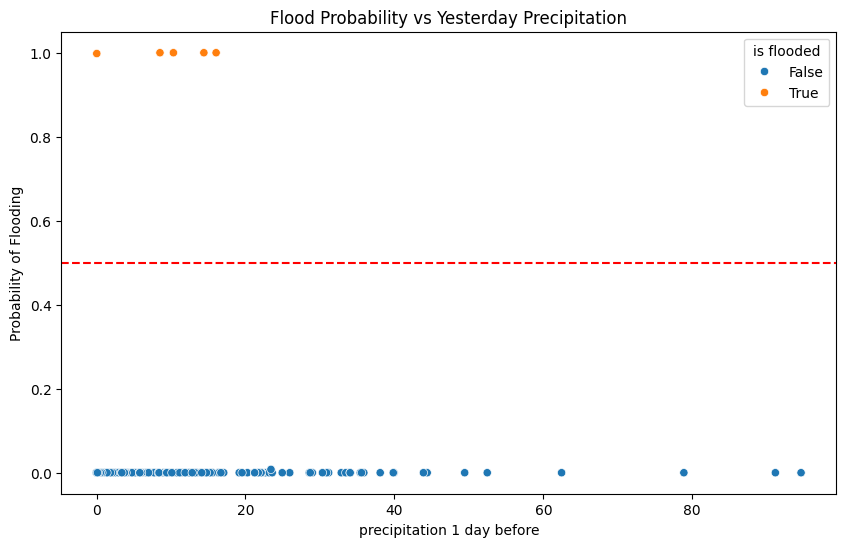

<Figure size 640x480 with 0 Axes>

In [137]:
# VISUALISATION OF FLOODING THRESHOLD
probabilities = model.predict_proba(X_test)[:,1]
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_test['precipitation 1 day before'], y= probabilities, hue=y_test)
plt.axhline(.5, color='red', linestyle='--')
plt.ylabel('Probability of Flooding')
plt.title('Flood Probability vs Yesterday Precipitation')
plt.show()
plt.savefig('flood probability classification.png',dpi=300)

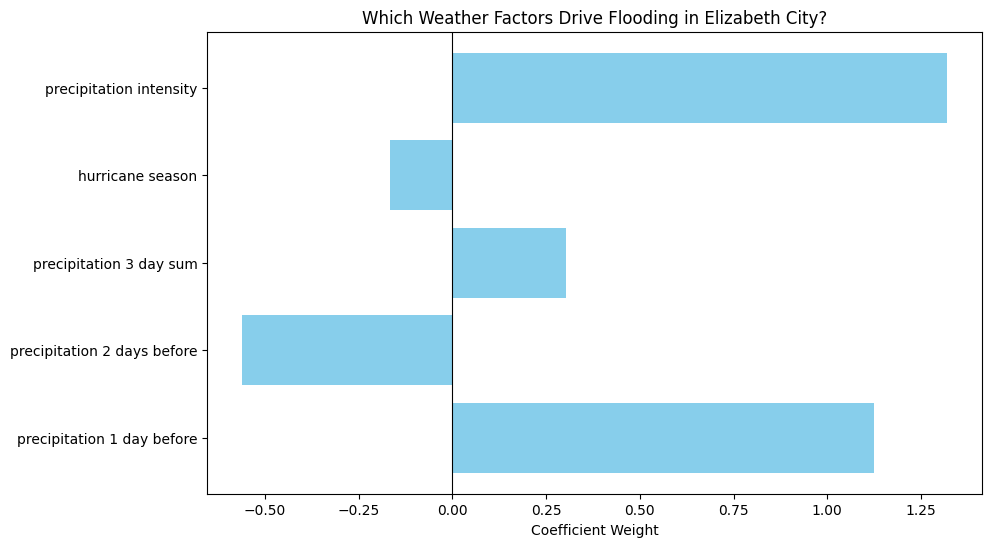

<Figure size 640x480 with 0 Axes>

In [138]:
# VISUALISATION of feature importance
importance = model.coef_[0]
feature_names = features

plt.figure(figsize=(10,6))
plt.barh(feature_names, importance, color='skyblue')
plt.xlabel('Coefficient Weight')
plt.title('Which Weather Factors Drive Flooding in Elizabeth City?')
plt.axvline(0, color='black',lw=0.8)
plt.show()
plt.savefig('flood prediction importance.png',dpi=300)

#ANALYSIS OF FLOOD PREDICTION MODEL FOR ELIZABETH CITY, NC

**Key Performance Metrics**:
 - *Overall Accuracy*: 99.8%
 - *Flood Recall*: 100%
 - *Precision*: 4/5 (80%)

**Primary Driving Factors for Flash Flooding**:
- High Increase in Precipitation on any day from the previous day was the strongest predictor for high flash flood risk.